# Notebook 6 — Final Business Report

## 1. Overview

Notebooks 1-5 completed the machine-learning work: exploration, preprocessing, a baseline,
a tuned final model, and evaluation with explainability. **This notebook trains nothing,
tunes nothing and changes nothing.** It loads the results those notebooks produced and
translates them into business terms.

It answers seven questions:

1. What problem are we solving?
2. Which model was selected?
3. How well does it perform?
4. Where does it perform better, and where worse?
5. What does the model rely on?
6. How could the prediction become a useful business measure?
7. What would be required before real-world use?

## 2. Business Problem

The central business question is:

> Can customer financial and retirement information be used to estimate an expected
> retirement fund, and provide a basis for assessing retirement readiness?

The model estimates one number for each customer: **`Expected_Retirement_Fund`**, a
projected retirement fund in dollars.

The useful business question is not only "how accurately can we predict a number?".
It is: **can this prediction help us understand whether a customer appears to be on track
toward a retirement-fund goal?** Answering that requires a second step, taken in Section 11:
comparing the prediction with a retirement goal.

Two things must stay separate throughout this report:

| Layer | What it is |
|---|---|
| Model output | Expected retirement fund (what the model was trained to predict) |
| Business measure | Funding gap and funding ratio (calculated after the prediction) |
| Business interpretation | Proposed retirement readiness (a business rule, not a model output) |

This is decision-support material, not financial advice. The dataset is **synthetic**, so
every result below describes a generated dataset and is not evidence about real savers.

In [1]:
import hashlib
import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

import sklearn
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    median_absolute_error,
    r2_score,
)
from sklearn.model_selection import train_test_split

# --- Configuration -------------------------------------------------------
TARGET_NAME = "Expected_Retirement_Fund"
RANDOM_STATE = 42          # the Notebook 2 split seed
TEST_SIZE = 0.20           # the Notebook 2 split proportion
DOLLAR_FLOOR = 1.0         # the floor Notebooks 4 and 5 used before taking logs
REPRODUCTION_TOLERANCE = 1e-6   # relative, for matching the Notebook 5 metrics

# Proposed readiness thresholds. These are business-design assumptions, not
# validated financial standards. Section 11 explains where each one comes from.
ON_TRACK_RATIO = 1.00
NEEDS_ATTENTION_RATIO = 0.75

# 04_final_model.joblib was pickled with this version and cannot be unpickled by
# scikit-learn 1.7+, so the notebook says what is needed instead of failing later.
ARTIFACT_SKLEARN_VERSION = "1.6.1"

print("pandas       ", pd.__version__)
print("numpy        ", np.__version__)
print("scikit-learn ", sklearn.__version__)
if sklearn.__version__ != ARTIFACT_SKLEARN_VERSION:
    print(f"\nWARNING: 04_final_model.joblib was saved with scikit-learn "
          f"{ARTIFACT_SKLEARN_VERSION}. If it fails to load, install the matching "
          f"versions and restart:")
    print("    pip install scikit-learn==1.6.1 pandas==2.2.3 numpy==2.1.3")

# Same visual identity as Notebooks 1-5.
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.dpi": 100,
    "savefig.dpi": 300,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "axes.edgecolor": "#CCCCCC",
    "grid.color": "#E8E8E8",
    "font.size": 10,
})

NAVY = "#1F3B73"
TEAL = "#2A9D8F"
AMBER = "#E9A13B"
CORAL = "#E76F51"
SLATE = "#6C757D"

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 120)

pandas        2.2.3
numpy         2.1.3
scikit-learn  1.6.1


In [2]:
# The project root is the folder that holds retirement_dataset_v2.csv. Earlier
# notebooks keep their outputs in their own folders (3/artifacts, 4/artifacts,
# 5/artifacts), so each file is located by searching the project tree once.
CANDIDATE_ROOTS = [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]

PROJECT_ROOT = None
for candidate in CANDIDATE_ROOTS:
    if candidate.exists() and any(candidate.rglob("retirement_dataset_v2.csv")):
        PROJECT_ROOT = candidate
        break
if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "Could not find the project root (the folder containing "
        "retirement_dataset_v2.csv). Checked: "
        + ", ".join(str(path) for path in CANDIDATE_ROOTS))


def find_project_file(filename):
    """Return the path of one project file, searched for under PROJECT_ROOT."""
    matches = sorted(path for path in PROJECT_ROOT.rglob(filename)
                     if ".ipynb_checkpoints" not in path.parts)
    if not matches:
        raise FileNotFoundError(f"{filename} was not found under {PROJECT_ROOT}")
    return matches[0]


REQUIRED_FILES = {
    "data": "retirement_dataset_v2.csv",
    "feature_engineering": "feature_engineering.py",
    "nb3_results": "03_baseline_model_results.csv",
    "nb4_model": "04_final_model.joblib",
    "nb4_config": "04_final_model_config.json",
    "nb4_results": "04_model_improvement_results.csv",
    "nb5_evaluation": "05_model_evaluation_results.csv",
    "nb5_segments": "05_error_by_segment.csv",
    "nb5_permutation": "05_permutation_importance.csv",
    "nb5_shap": "05_shap_importance.csv",
}
PATHS = {key: find_project_file(name) for key, name in REQUIRED_FILES.items()}

# The saved pipeline rebuilds its feature-engineering step from src/, so that
# module must be importable before the model is loaded. Bytecode caching is turned
# off first so that importing it leaves no __pycache__ folder in src/: this
# notebook writes nothing outside its own artifacts/ and figures/ folders.
sys.dont_write_bytecode = True

SOURCE_ROOT = PATHS["feature_engineering"].parent.parent
if str(SOURCE_ROOT) not in sys.path:
    sys.path.insert(0, str(SOURCE_ROOT))

# Notebook 6 writes its own outputs next to itself and leaves every earlier
# artifact untouched.
ARTIFACTS_DIR = Path.cwd() / "artifacts"
FIGURES_DIR = Path.cwd() / "figures"
ARTIFACTS_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(exist_ok=True)

# Fingerprint every file this notebook must not change. Section 20 re-hashes them.
PROTECTED_FILES = sorted(
    path for path in PROJECT_ROOT.rglob("*")
    if path.is_file()
    and ".ipynb_checkpoints" not in path.parts
    and Path.cwd() not in path.parents          # Notebook 6's own folder is excluded
    and path.suffix in {".ipynb", ".py", ".csv", ".json", ".joblib", ".png", ".gz", ".md"}
)


def hash_files(paths):
    """sha256 of each file, so 'nothing else changed' can be proven, not claimed."""
    return {str(path): hashlib.sha256(path.read_bytes()).hexdigest() for path in paths}


PROTECTED_HASHES_BEFORE = hash_files(PROTECTED_FILES)

# --- Load the results the earlier notebooks recorded ---------------------
final_config = json.loads(PATHS["nb4_config"].read_text())
notebook3_results = pd.read_csv(PATHS["nb3_results"], index_col=0)
notebook4_results = pd.read_csv(PATHS["nb4_results"], index_col=0)
evaluation_results = pd.read_csv(PATHS["nb5_evaluation"], index_col=0)
segment_errors = pd.read_csv(PATHS["nb5_segments"])
permutation_importance_results = pd.read_csv(PATHS["nb5_permutation"], index_col=0)
shap_importance = pd.read_csv(PATHS["nb5_shap"], index_col=0)

BASELINE_NAME = "Baseline GB (Notebook 3)"
FINAL_NAME = final_config["candidate"]
nb5_baseline = evaluation_results.loc[BASELINE_NAME]
nb5_final = evaluation_results.loc[FINAL_NAME]

print("Project root:", PROJECT_ROOT)
for key, path in PATHS.items():
    print(f"   {path.name:<38} {path.relative_to(PROJECT_ROOT)}")
print()
print(f"Notebook 6 outputs -> {ARTIFACTS_DIR} and {FIGURES_DIR}")
print(f"Files fingerprinted and protected from change: {len(PROTECTED_HASHES_BEFORE)}")

Project root: /sessions/rcw-01uufa4rengyrpyytzvysgom/mnt/Claude- ML
   retirement_dataset_v2.csv              retirement_dataset_v2.csv
   feature_engineering.py                 3/src/feature_engineering.py
   03_baseline_model_results.csv          3/artifacts/03_baseline_model_results.csv
   04_final_model.joblib                  4/artifacts/04_final_model.joblib
   04_final_model_config.json             4/artifacts/04_final_model_config.json
   04_model_improvement_results.csv       4/artifacts/04_model_improvement_results.csv
   05_model_evaluation_results.csv        5/artifacts/05_model_evaluation_results.csv
   05_error_by_segment.csv                5/artifacts/05_error_by_segment.csv
   05_permutation_importance.csv          5/artifacts/05_permutation_importance.csv
   05_shap_importance.csv                 5/artifacts/05_shap_importance.csv

Notebook 6 outputs -> /sessions/rcw-01uufa4rengyrpyytzvysgom/mnt/Claude- ML/6/artifacts and /sessions/rcw-01uufa4rengyrpyytzvysgom/mnt/Clau

---
## 3. Data Overview

A compact profile of the data behind the model. The full exploratory analysis is in
Notebook 1 and is not repeated here. Every value below is read from the project files.

In [3]:
# Notebook 2's recipe, unchanged: drop the identifier, the three target-derived KPI
# columns and the target, remove exact duplicates, then split 80/20 with
# random_state=42. Notebook 5 verified that this rebuild reproduces the Notebook 4
# test metrics exactly, so it is reused here rather than re-derived.
IDENTIFIER_COLUMNS = ["CustomerID"]
KPI_COLUMNS = ["Readiness_Score", "Funding_Gap", "RetirementReady"]

raw_data = pd.read_csv(PATHS["data"])
features = raw_data.drop(columns=IDENTIFIER_COLUMNS + KPI_COLUMNS + [TARGET_NAME])
target = raw_data[TARGET_NAME]
rows_to_keep = ~raw_data.duplicated(keep="first")

X_train_raw, X_test_raw, _, y_test_dollars = train_test_split(
    features[rows_to_keep], target[rows_to_keep],
    test_size=TEST_SIZE, random_state=RANDOM_STATE,
)
test_actual_dollars = y_test_dollars.to_numpy()

data_overview = pd.DataFrame([
    ("Records in the source file", f"{len(raw_data):,}"),
    ("Exact duplicate records removed", f"{int(raw_data.duplicated().sum()):,}"),
    ("Records available for modelling", f"{int(rows_to_keep.sum()):,}"),
    ("Training records", f"{len(X_train_raw):,}"),
    ("Test records (never used to choose the model)", f"{len(X_test_raw):,}"),
    ("Raw customer columns given to the pipeline", f"{X_test_raw.shape[1]}"),
    ("Model features after preprocessing", f"{final_config['n_model_features']}"),
    ("Target variable", TARGET_NAME),
    ("Target units", "US dollars"),
    ("Columns excluded as target leakage", ", ".join(KPI_COLUMNS)),
    ("Data source", "Synthetic - generated data, not real customers"),
], columns=["Item", "Value"]).set_index("Item")

print(data_overview.to_string())
print()
print(f"Median actual retirement fund in the test set: ${np.median(test_actual_dollars):,.0f}")
print(f"Mean actual retirement fund in the test set:   ${test_actual_dollars.mean():,.0f}")

assert len(X_train_raw) == final_config["n_training_rows"], "Training split does not match Notebook 4."

                                                                                        Value
Item                                                                                         
Records in the source file                                                             30,000
Exact duplicate records removed                                                           150
Records available for modelling                                                        29,850
Training records                                                                       23,880
Test records (never used to choose the model)                                           5,970
Raw customer columns given to the pipeline                                                 27
Model features after preprocessing                                                         40
Target variable                                                      Expected_Retirement_Fund
Target units                                                

---
## 4. The Machine Learning Journey

One place for a business reader to see how the project reached its final model. Each
outcome below is taken from the results files those notebooks saved.

In [4]:
nb3_test_row = notebook3_results[notebook3_results.Stage == "Test set"].iloc[0]
top_drivers = list(shap_importance.head(3).index)

journey = pd.DataFrame([
    ("Notebook 1", "Exploratory data analysis",
     f"The target is strongly right-skewed, which supports modelling on log(target). "
     f"{', '.join(KPI_COLUMNS)} are derived from the target and were removed as leakage. "
     f"Age shows a curved rather than linear relationship with the target."),
    ("Notebook 2", "Preprocessing and feature engineering",
     f"A leakage-safe pipeline producing {len(X_train_raw):,} training and "
     f"{len(X_test_raw):,} test rows with {final_config['n_model_features']} model features, "
     f"5 of them engineered. All imputation and encoding is learned from training data only."),
    ("Notebook 3", "Baseline model training",
     f"Gradient Boosting was the strongest of the seven baselines tested and clearly beat the "
     f"linear models. Test dollar RMSE ${float(nb3_test_row['RMSE ($)']):,.0f}."),
    ("Notebook 4", "Model improvement",
     f"Tuned Gradient Boosting on a log target with a smearing correction was selected on "
     f"cross-validated dollar RMSE (${final_config['cv_selection_score']:,.0f}) using training data only. "
     f"The test set was opened once, after selection."),
    ("Notebook 5", "Evaluation and explainability",
     f"Final test dollar RMSE ${float(nb5_final['RMSE ($)']):,.0f} against a baseline of "
     f"${float(nb5_baseline['RMSE ($)']):,.0f}. Built-in importance, permutation importance and SHAP "
     f"agree on the same leading features: {', '.join(top_drivers)}."),
], columns=["Notebook", "Purpose", "Main outcome"]).set_index("Notebook")

for notebook, row in journey.iterrows():
    print(f"{notebook} - {row['Purpose']}")
    print(f"   {row['Main outcome']}")
    print()

Notebook 1 - Exploratory data analysis
   The target is strongly right-skewed, which supports modelling on log(target). Readiness_Score, Funding_Gap, RetirementReady are derived from the target and were removed as leakage. Age shows a curved rather than linear relationship with the target.

Notebook 2 - Preprocessing and feature engineering
   A leakage-safe pipeline producing 23,880 training and 5,970 test rows with 40 model features, 5 of them engineered. All imputation and encoding is learned from training data only.

Notebook 3 - Baseline model training
   Gradient Boosting was the strongest of the seven baselines tested and clearly beat the linear models. Test dollar RMSE $1,266,265.

Notebook 4 - Model improvement
   Tuned Gradient Boosting on a log target with a smearing correction was selected on cross-validated dollar RMSE ($1,205,619) using training data only. The test set was opened once, after selection.

Notebook 5 - Evaluation and explainability
   Final test dollar RMSE 

---
## 5. The Final Model

The final model was selected and frozen in Notebook 4. Its configuration is read from
`04_final_model_config.json`; nothing is typed in by hand and nothing is retrained.

**Gradient Boosting, in business language.** The model is a large collection of small
decision rules, built one after another. Each new rule concentrates on the customers the
previous rules got wrong, and the final estimate is the sum of all of them. That is why it
handles curved and interacting relationships, such as the effect of age, better than a
straight-line model.

**The prediction recipe.** The model was trained on the logarithm of the fund, because the
target is strongly right-skewed. Its output is therefore converted back to dollars, then
multiplied by a fixed *smearing factor* that corrects the small shortfall this conversion
introduces when predictions are added together.

In [5]:
final_model = joblib.load(PATHS["nb4_model"])
gradient_boosting = final_model.named_steps["model"]

print("Configuration read from 04_final_model_config.json")
print(f"   candidate            {final_config['candidate']}")
print(f"   algorithm            {type(gradient_boosting).__name__}")
print(f"   target scale         {final_config['target_scale']}")
print(f"   smearing correction  {final_config['smearing']} "
      f"(factor {final_config['smearing_factor']:.6f})")
print(f"   selection metric     {final_config['selection_metric']} "
      f"({final_config['cv_folds']}-fold CV on training data)")
print(f"   random_state         {final_config['random_state']}")
print("   hyperparameters:")
for key, value in final_config["model_params"].items():
    print(f"      {key:<18} {value}")
print(f"\nPrediction recipe: exp(log prediction) x {final_config['smearing_factor']:.6f}")

# Notebook 6 only calls predict(). Nothing is fitted here.
X_test_transformed = final_model[:-1].transform(X_test_raw)
model_feature_names = list(X_test_transformed.columns)

predicted_dollars = final_model.predict(X_test_raw)
if final_config["target_scale"] == "log":
    predicted_dollars = np.exp(predicted_dollars) * final_config["smearing_factor"]


def score_predictions(actual_dollars, predicted):
    """The Notebook 5 metric set, so the two notebooks are directly comparable."""
    actual_log = np.log(actual_dollars)
    predicted_log = np.log(np.clip(predicted, DOLLAR_FLOOR, None))
    return {
        "R2 (log)": r2_score(actual_log, predicted_log),
        "R2 ($)": r2_score(actual_dollars, predicted),
        "RMSE ($)": np.sqrt(mean_squared_error(actual_dollars, predicted)),
        "MAE ($)": mean_absolute_error(actual_dollars, predicted),
        "MedianAE ($)": median_absolute_error(actual_dollars, predicted),
        "MAPE (%)": np.mean(np.abs((actual_dollars - predicted) / actual_dollars)) * 100,
    }


HEADLINE_METRICS = ["R2 (log)", "R2 ($)", "RMSE ($)", "MAE ($)", "MedianAE ($)", "MAPE (%)"]
final_scores = score_predictions(test_actual_dollars, predicted_dollars)

# Integrity check: these predictions must reproduce what Notebook 5 recorded.
reproduction_gap = max(abs(final_scores[metric] / float(nb5_final[metric]) - 1)
                       for metric in HEADLINE_METRICS)

print(f"\nPredicted {len(predicted_dollars):,} test customers.")
print(f"Largest relative difference vs 05_model_evaluation_results.csv: {reproduction_gap:.2e}")

assert reproduction_gap <= REPRODUCTION_TOLERANCE, "Predictions do not match Notebook 5."
assert gradient_boosting.n_estimators_ == final_config["model_params"]["n_estimators"], \
    "The model does not have the number of trees the saved configuration records."
print("The frozen Notebook 4 model reproduces the Notebook 5 results. No model was fitted here.")

Configuration read from 04_final_model_config.json
   candidate            Tuned GB (log + smearing)
   algorithm            GradientBoostingRegressor
   target scale         log
   smearing correction  True (factor 1.028933)
   selection metric     RMSE ($) (5-fold CV on training data)
   random_state         42
   hyperparameters:
      subsample          0.8
      n_estimators       600
      min_samples_leaf   5
      max_depth          4
      learning_rate      0.05

Prediction recipe: exp(log prediction) x 1.028933



Predicted 5,970 test customers.
Largest relative difference vs 05_model_evaluation_results.csv: 5.55e-16
The frozen Notebook 4 model reproduces the Notebook 5 results. No model was fitted here.


---
## 6. Final Model Performance

Results on the sealed test set of customers the model never saw during training or model
selection. What each headline number means in practical terms:

- **RMSE (dollars)** — squares each error before averaging, so a few very large misses
  dominate it. Read it as the metric that is most sensitive to big, expensive mistakes.
- **MAE (dollars)** — the average size of the error, in dollars, treating every customer
  equally.
- **Median absolute error (dollars)** — the middle error. Half of customers are predicted
  more accurately than this. Because it ignores the extremes, the gap between it and RMSE
  tells you how much a small number of large errors is inflating the average.
- **MAPE (%)** — the average error *relative to the customer's own fund*. A fixed dollar
  error matters far more to a small fund than a large one, so this is the fairer view for
  a typical customer.
- **R-squared** — the share of variation the model explains. It is reported in both log
  space, where the model was trained, and in dollars, where the business reads results.

In [6]:
METRIC_LABELS = {
    "R2 (log)": "R-squared (log scale, where the model is trained)",
    "R2 ($)": "R-squared (dollars)",
    "RMSE ($)": "RMSE - root mean squared error (dollars)",
    "MAE ($)": "MAE - mean absolute error (dollars)",
    "MedianAE ($)": "Median absolute error (dollars)",
    "MAPE (%)": "MAPE - mean absolute percentage error",
}


# Short names for chart labels; METRIC_LABELS is the long form used in tables.
SHORT_LABELS = {
    "R2 (log)": "R-squared (log)",
    "R2 ($)": "R-squared (dollars)",
    "RMSE ($)": "RMSE",
    "MAE ($)": "MAE",
    "MedianAE ($)": "Median AE",
    "MAPE (%)": "MAPE",
}
MONEY_METRICS = {"RMSE ($)", "MAE ($)", "MedianAE ($)"}
PERCENT_METRICS = {"MAPE (%)"}


def format_money(value):
    """Dollars with the minus sign outside, so -$1,000 rather than $-1,000."""
    return f"-${abs(value):,.0f}" if value < 0 else f"${value:,.0f}"


def format_signed_money(value):
    """Dollars with an explicit sign, for errors and differences."""
    return f"{'+' if value >= 0 else '-'}${abs(value):,.0f}"


def format_metric(metric, value):
    """R-squared is a ratio, not a dollar amount, so it is not given a currency sign."""
    if metric in MONEY_METRICS:
        return format_money(value)
    if metric in PERCENT_METRICS:
        return f"{value:.1f}%"
    return f"{value:.4f}"


kpi_table = pd.DataFrame([
    {"Business KPI": METRIC_LABELS[metric], "Test-set result": format_metric(metric, final_scores[metric])}
    for metric in HEADLINE_METRICS
]).set_index("Business KPI")

print(f"Final model performance on {len(X_test_raw):,} unseen test customers")
print(kpi_table.to_string())

absolute_error = np.abs(predicted_dollars - test_actual_dollars)
absolute_percentage_error = absolute_error / test_actual_dollars * 100

print("\nThe same result, expressed for a business audience:")
print(f"   Typical (median) miss                    ${np.median(absolute_error):,.0f}")
print(f"   Median error relative to the customer    {np.median(absolute_percentage_error):.1f}%")
print(f"   Customers predicted within 10% of actual {(absolute_percentage_error <= 10).mean() * 100:.1f}%")
print(f"   Customers predicted within 25% of actual {(absolute_percentage_error <= 25).mean() * 100:.1f}%")
print(f"   Customers predicted within 50% of actual {(absolute_percentage_error <= 50).mean() * 100:.1f}%")
print(f"\nRMSE is {final_scores['RMSE ($)'] / final_scores['MedianAE ($)']:.1f}x the median absolute error, "
      f"which confirms that a small number of large misses drives it.")

Final model performance on 5,970 unseen test customers
                                                  Test-set result
Business KPI                                                     
R-squared (log scale, where the model is trained)          0.9022
R-squared (dollars)                                        0.8515
RMSE - root mean squared error (dollars)               $1,231,163
MAE - mean absolute error (dollars)                      $753,165
Median absolute error (dollars)                          $436,662
MAPE - mean absolute percentage error                       21.0%

The same result, expressed for a business audience:
   Typical (median) miss                    $436,662
   Median error relative to the customer    14.9%
   Customers predicted within 10% of actual 35.3%
   Customers predicted within 25% of actual 72.7%
   Customers predicted within 50% of actual 91.8%

RMSE is 2.8x the median absolute error, which confirms that a small number of large misses drives it.


---
## 7. Baseline vs Final Model

The business question for this section is simple: **did the model-improvement work in
Notebook 4 actually improve predictive performance?**

Both rows come from `05_model_evaluation_results.csv`, where Notebook 5 scored the
Notebook 3 baseline and the Notebook 4 final model on the same test customers with the
same metric definitions. Every change below is calculated, not typed. Metrics that did not
improve are shown alongside the ones that did.

                                                  Notebook 3 baseline Notebook 4 final  Change vs baseline (%) Improved?
Metric                                                                                                                  
RMSE - root mean squared error (dollars)                   $1,266,265       $1,231,163                   -2.77       yes
MAE - mean absolute error (dollars)                          $769,677         $753,165                   -2.15       yes
Median absolute error (dollars)                              $448,701         $436,662                   -2.68       yes
MAPE - mean absolute percentage error                           21.3%            21.0%                   -1.26       yes
R-squared (dollars)                                            0.8429           0.8515                   +1.02       yes
R-squared (log scale, where the model is trained)              0.8962           0.9022                   +0.68       yes

'Change vs baseline (%)' is the

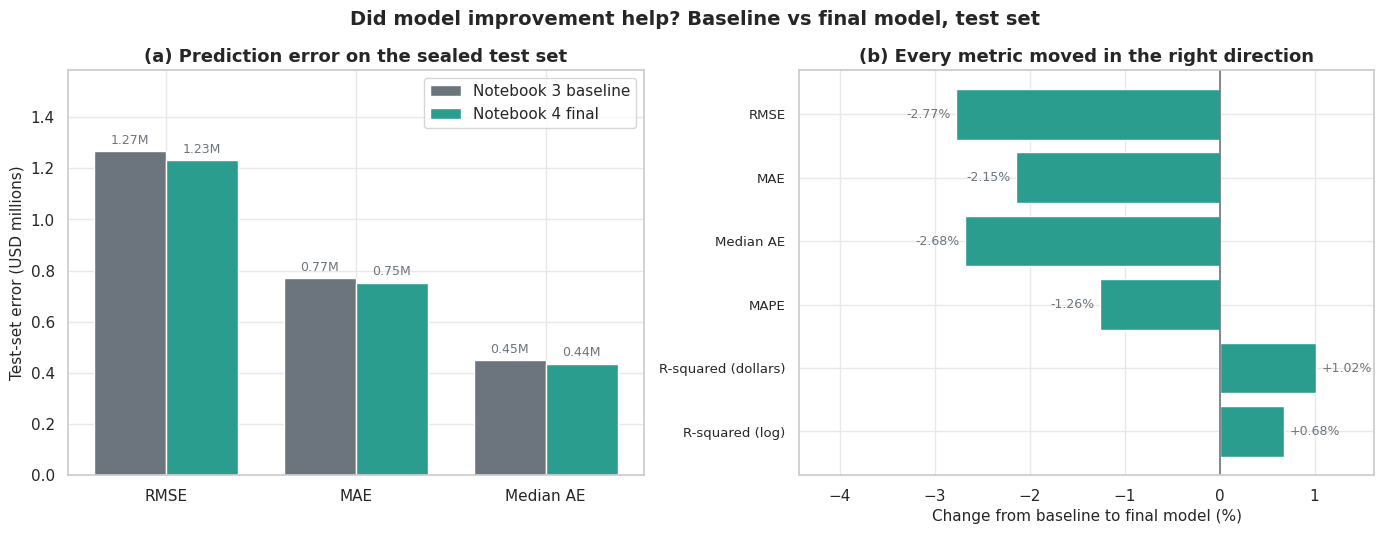

In [7]:
COMPARISON_METRICS = ["RMSE ($)", "MAE ($)", "MedianAE ($)", "MAPE (%)", "R2 ($)", "R2 (log)"]
LOWER_IS_BETTER = {"RMSE ($)", "MAE ($)", "MedianAE ($)", "MAPE (%)"}

rows = []
for metric in COMPARISON_METRICS:
    before = float(nb5_baseline[metric])
    after = float(nb5_final[metric])
    improved = after < before if metric in LOWER_IS_BETTER else after > before
    rows.append({
        "Metric": METRIC_LABELS[metric],
        "Notebook 3 baseline": format_metric(metric, before),
        "Notebook 4 final": format_metric(metric, after),
        "Change vs baseline (%)": (after / before - 1) * 100,
        "Improved?": "yes" if improved else "no",
    })
comparison = pd.DataFrame(rows).set_index("Metric")

print(comparison.to_string(float_format=lambda value: f"{value:+.2f}"))
print()
print("'Change vs baseline (%)' is the relative change in each metric. MAPE is already a")
print(f"percentage, so its absolute change is "
      f"{float(nb5_final['MAPE (%)']) - float(nb5_baseline['MAPE (%)']):+.2f} percentage points.")
print()
print(f"Aggregate bias (predicted portfolio total vs actual): "
      f"{float(nb5_baseline['Aggregate bias (%)']):+.2f}% -> "
      f"{float(nb5_final['Aggregate bias (%)']):+.2f}%")
print()
print("Honest reading:")
print(f"   Every error metric improved, but only modestly: dollar RMSE fell "
      f"{-(float(nb5_final['RMSE ($)']) / float(nb5_baseline['RMSE ($)']) - 1) * 100:.1f}%.")
print(f"   Relative error barely moved: MAPE changed by "
      f"{float(nb5_final['MAPE (%)']) - float(nb5_baseline['MAPE (%)']):+.2f} percentage points.")
print(f"   The clearest gain is the portfolio total, where the shortfall shrank from "
      f"{abs(float(nb5_baseline['Aggregate bias (%)'])):.1f}% to "
      f"{abs(float(nb5_final['Aggregate bias (%)'])):.1f}%. That matters when predictions are summed.")

# --- FIGURE 1: baseline vs final -----------------------------------------
dollar_metrics = ["RMSE ($)", "MAE ($)", "MedianAE ($)"]
short_labels = ["RMSE", "MAE", "Median AE"]
baseline_values = [float(nb5_baseline[metric]) / 1e6 for metric in dollar_metrics]
final_values = [float(nb5_final[metric]) / 1e6 for metric in dollar_metrics]

fig, axes = plt.subplots(1, 2, figsize=(14, 5.4))
offsets = np.arange(len(dollar_metrics))

axes[0].bar(offsets - 0.19, baseline_values, width=0.38, color=SLATE,
            edgecolor="white", label="Notebook 3 baseline")
axes[0].bar(offsets + 0.19, final_values, width=0.38, color=TEAL,
            edgecolor="white", label="Notebook 4 final")
for offset, before, after in zip(offsets, baseline_values, final_values):
    axes[0].text(offset - 0.19, before + 0.03, f"{before:.2f}M", ha="center", fontsize=9, color=SLATE)
    axes[0].text(offset + 0.19, after + 0.03, f"{after:.2f}M", ha="center", fontsize=9, color=SLATE)
axes[0].set_xticks(offsets)
axes[0].set_xticklabels(short_labels)
axes[0].set_ylabel("Test-set error (USD millions)")
axes[0].set_ylim(0, max(baseline_values + final_values) * 1.25)
axes[0].set_title("(a) Prediction error on the sealed test set")
axes[0].legend(frameon=True)

changes = comparison["Change vs baseline (%)"].to_numpy()
change_labels = [SHORT_LABELS[metric] for metric in COMPARISON_METRICS]
colours = [TEAL if improved == "yes" else CORAL for improved in comparison["Improved?"]]
positions = np.arange(len(changes))[::-1]
axes[1].barh(positions, changes, color=colours, edgecolor="white")
axes[1].axvline(0, color=SLATE, lw=1.2)
axes[1].set_yticks(positions)
axes[1].set_yticklabels(change_labels, fontsize=9.5)
axes[1].set_xlabel("Change from baseline to final model (%)")
axes[1].set_title("(b) Every metric moved in the right direction")
for position, value in zip(positions, changes):
    axes[1].text(value + (0.06 if value >= 0 else -0.06), position, f"{value:+.2f}%",
                 va="center", ha="left" if value >= 0 else "right", fontsize=9, color=SLATE)
axes[1].set_xlim(min(changes) * 1.6, max(changes) * 1.6)

fig.suptitle("Did model improvement help? Baseline vs final model, test set",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "06_baseline_vs_final.png", dpi=300, bbox_inches="tight",
            facecolor="white")
plt.show()

---
## 8. Where the Model Performs Well

## 9. Where the Model Struggles

These two sections use the same source: `05_error_by_segment.csv`, the segment analysis
Notebook 5 produced. No new segments are invented here.

The important distinction is between **relative error** and **absolute dollar error**,
because they point at different customers:

- **Relative error (MAPE)** answers *"how wrong are we, as a share of this customer's own
  fund?"*. A 100,000 dollar miss on a small fund is a serious error; the same miss on a
  multi-million dollar fund is not. Relative error is the fairer measure of whether an
  individual customer's estimate is trustworthy.
- **Absolute dollar error (MAE, RMSE)** answers *"how many dollars are we off by?"*. It is
  driven by the largest funds and is what matters when predictions are added together for
  a portfolio or balance-sheet view.

A segment can therefore look good on one measure and poor on the other, and the highest
income quintile is exactly that case. The table and chart below show both side by side.

Income group (salary quintile)
              Customers  Median actual fund ($)  Mean absolute error ($)  Median absolute error ($)  Relative error, mean (%)  Relative error, median (%)
Segment                                                                                                                                                  
Q1 (lowest)        1189             1,021,045.2                287,908.0                  155,688.0                      25.7                        17.6
Q2                 1212             2,458,323.5                517,557.1                  350,672.2                      20.9                        14.6
Q3                 1188             3,365,653.3                709,491.5                  474,608.1                      20.5                        14.4
Q4                 1203             4,415,430.5                842,625.6                  571,632.2                      18.5                        13.4
Q5 (highest)       1178             6,745,854

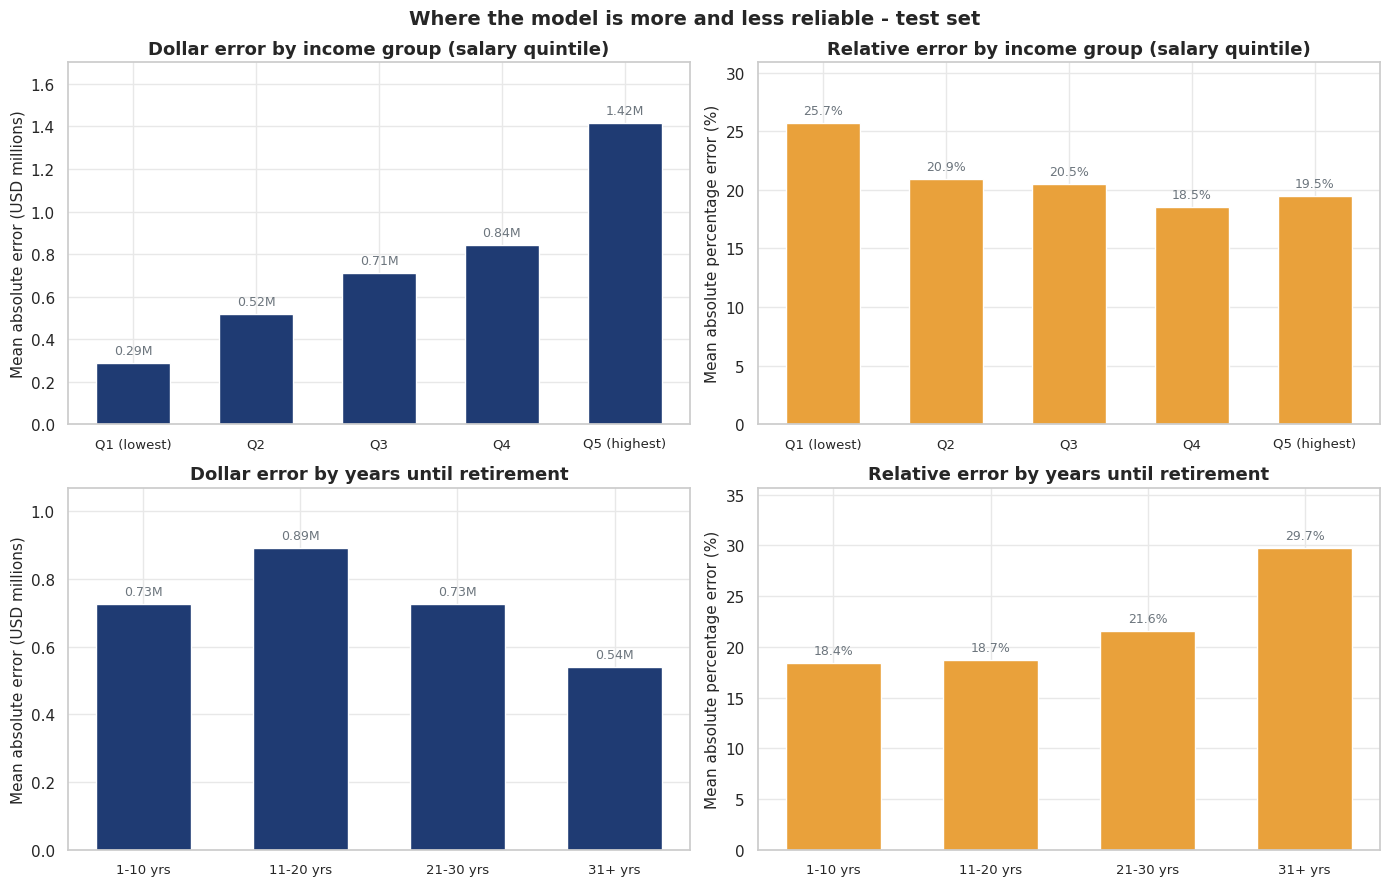

In [8]:
SEGMENT_LABELS = {
    "IncomeQuintile": "Income group (salary quintile)",
    "HorizonBand": "Years until retirement",
    "PredictedFundQuintile": "Predicted fund size",
}

business_segments = segment_errors.rename(columns={
    "segmentation": "Segmentation",
    "segment": "Segment",
    "customers": "Customers",
    "median_actual": "Median actual fund ($)",
    "MAE": "Mean absolute error ($)",
    "MedianAE": "Median absolute error ($)",
    "MAPE": "Relative error, mean (%)",
    "median_APE": "Relative error, median (%)",
})[["Segmentation", "Segment", "Customers", "Median actual fund ($)",
    "Mean absolute error ($)", "Median absolute error ($)",
    "Relative error, mean (%)", "Relative error, median (%)"]]

for segmentation, group in business_segments.groupby("Segmentation", sort=False):
    print(f"{SEGMENT_LABELS[segmentation]}")
    print(group.drop(columns="Segmentation").set_index("Segment").to_string(
        float_format=lambda value: f"{value:,.1f}"))
    best = group.loc[group["Relative error, mean (%)"].idxmin()]
    worst = group.loc[group["Relative error, mean (%)"].idxmax()]
    costly = group.loc[group["Mean absolute error ($)"].idxmax()]
    print(f"   Smallest relative error: {best['Segment']} ({best['Relative error, mean (%)']:.1f}%)")
    print(f"   Largest relative error:  {worst['Segment']} ({worst['Relative error, mean (%)']:.1f}%)")
    print(f"   Largest dollar error:    {costly['Segment']} "
          f"(${costly['Mean absolute error ($)']:,.0f} mean absolute error)")
    print()

income = business_segments[business_segments.Segmentation == "IncomeQuintile"]
top_income = income.iloc[-1]
bottom_income = income.iloc[0]
print("The clearest example of the two views disagreeing:")
print(f"   {bottom_income['Segment']:<14} relative error {bottom_income['Relative error, mean (%)']:.1f}%  "
      f"dollar error ${bottom_income['Mean absolute error ($)']:,.0f}")
print(f"   {top_income['Segment']:<14} relative error {top_income['Relative error, mean (%)']:.1f}%  "
      f"dollar error ${top_income['Mean absolute error ($)']:,.0f}")
print(f"   The highest income group is predicted more accurately in percentage terms but "
      f"carries {top_income['Mean absolute error ($)'] / bottom_income['Mean absolute error ($)']:.1f}x "
      f"the dollar error, so it dominates RMSE.")

# --- FIGURE 2: error by business segment ---------------------------------
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

for row, segmentation in enumerate(["IncomeQuintile", "HorizonBand"]):
    group = business_segments[business_segments.Segmentation == segmentation]
    positions = np.arange(len(group))
    label = SEGMENT_LABELS[segmentation]

    dollar_values = group["Mean absolute error ($)"] / 1e6
    axes[row, 0].bar(positions, dollar_values, color=NAVY, edgecolor="white", width=0.6)
    axes[row, 0].set_xticks(positions)
    axes[row, 0].set_xticklabels(group["Segment"], fontsize=9.5)
    axes[row, 0].set_ylabel("Mean absolute error (USD millions)")
    axes[row, 0].set_title(f"Dollar error by {label.lower()}")
    axes[row, 0].set_ylim(0, dollar_values.max() * 1.2)
    for position, value in zip(positions, dollar_values):
        axes[row, 0].text(position, value + dollar_values.max() * 0.03, f"{value:.2f}M",
                          ha="center", fontsize=9, color=SLATE)

    percent_values = group["Relative error, mean (%)"]
    axes[row, 1].bar(positions, percent_values, color=AMBER, edgecolor="white", width=0.6)
    axes[row, 1].set_xticks(positions)
    axes[row, 1].set_xticklabels(group["Segment"], fontsize=9.5)
    axes[row, 1].set_ylabel("Mean absolute percentage error (%)")
    axes[row, 1].set_title(f"Relative error by {label.lower()}")
    axes[row, 1].set_ylim(0, percent_values.max() * 1.2)
    for position, value in zip(positions, percent_values):
        axes[row, 1].text(position, value + percent_values.max() * 0.03, f"{value:.1f}%",
                          ha="center", fontsize=9, color=SLATE)

fig.suptitle("Where the model is more and less reliable - test set",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "06_error_by_segment.png", dpi=300, bbox_inches="tight",
            facecolor="white")
plt.show()

---
## 10. What Drives the Predictions?

Notebook 5 measured feature importance three ways: the model's own built-in importance,
permutation importance (shuffle a column and see how much worse the predictions get), and
SHAP (how much each feature moved each individual prediction). The ranking below combines
all three; the chart shows the SHAP view, which weights every customer equally.

**One caution, and it matters for how this is used.** These methods describe **what the
model relies on**, not **what causes retirement wealth**. The project has not established
causality and cannot. A feature can rank highly because it is genuinely informative,
because it overlaps with another feature, or simply because of how this synthetic dataset
was generated. Nothing here supports a claim that changing one of these variables would
change a customer's retirement outcome.

Top 10 features the model relies on (ranked by SHAP, all three methods shown)
                          SHAP share (%)  SHAP rank  Permutation rank  Built-in rank
SalaryBasedContribution             20.6          1                 3              1
RetirementAccountBalance            19.3          2                 2              2
YearsUntilRetirement                19.0          3                 1              4
EmployerPension_Yes                  7.8          4                 6              7
InvestmentBalance                    5.3          5                 4              3
Savings                              4.1          6                 5             11
EmergencyFund                        3.5          7                 9              5
RiskTolerance                        2.8          8                 7              9
ExpectedAnnualReturn                 2.8          9                 8             10
AnnualSalary                         1.7         10                13   

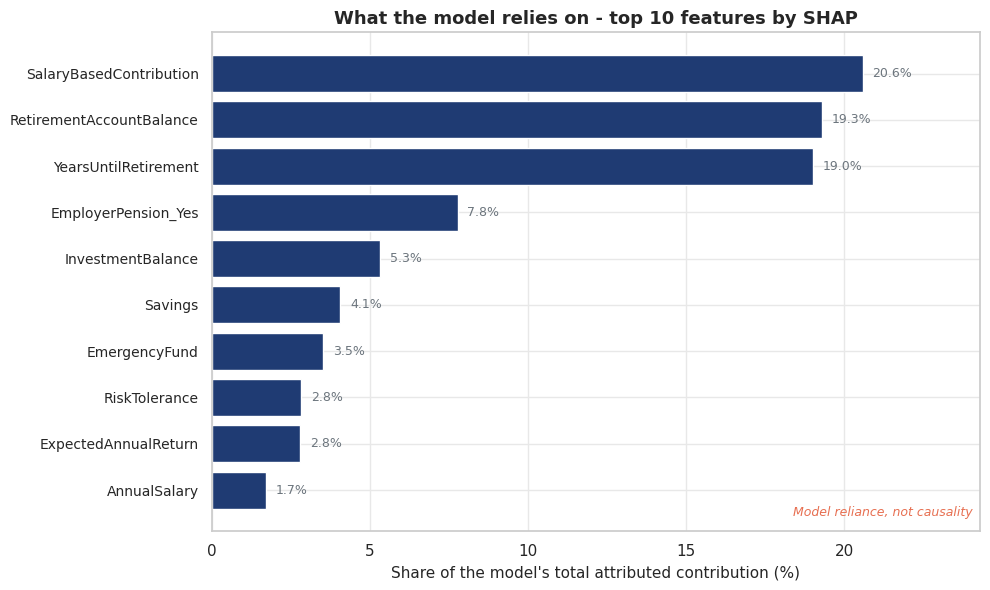

In [9]:
builtin_importance = pd.Series(
    gradient_boosting.feature_importances_, index=model_feature_names, name="builtin")

drivers = pd.DataFrame({
    "SHAP share (%)": shap_importance["share (%)"],
    "SHAP rank": shap_importance["mean |SHAP| (log)"].rank(ascending=False).astype(int),
    "Permutation rank": permutation_importance_results["RMSE ($) increase"].rank(ascending=False).astype(int),
    "Built-in rank": builtin_importance.rank(ascending=False).astype(int),
}).sort_values("SHAP share (%)", ascending=False)

TOP_N = 10
top_drivers_table = drivers.head(TOP_N)

print(f"Top {TOP_N} features the model relies on (ranked by SHAP, all three methods shown)")
print(top_drivers_table.to_string(float_format=lambda value: f"{value:,.1f}"))
print()
print(f"These {TOP_N} features account for {top_drivers_table['SHAP share (%)'].sum():.1f}% "
      f"of the model's total attributed contribution.")
print(f"The top 3 alone account for {drivers['SHAP share (%)'].head(3).sum():.1f}%.")
print()
print("Top 3 by each method:")
print(f"   SHAP        {', '.join(drivers.sort_values('SHAP rank').head(3).index)}")
print(f"   Permutation {', '.join(drivers.sort_values('Permutation rank').head(3).index)}")
print(f"   Built-in    {', '.join(drivers.sort_values('Built-in rank').head(3).index)}")
print()
print("The three methods agree on the same leading features but order them differently.")
print("Permutation importance is scored on dollar RMSE, which is dominated by the largest")
print("funds, so it favours the retirement-horizon feature. SHAP weights every customer")
print("equally. Both describe model reliance, not cause and effect.")

# --- FIGURE 3: top model drivers -----------------------------------------
plot_data = top_drivers_table["SHAP share (%)"].iloc[::-1]
positions = np.arange(len(plot_data))

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(positions, plot_data.to_numpy(), color=NAVY, edgecolor="white")
ax.set_yticks(positions)
ax.set_yticklabels(plot_data.index, fontsize=10)
ax.set_xlabel("Share of the model's total attributed contribution (%)")
ax.set_title(f"What the model relies on - top {TOP_N} features by SHAP")
ax.set_xlim(0, plot_data.max() * 1.18)
for position, value in zip(positions, plot_data):
    ax.text(value + plot_data.max() * 0.015, position, f"{value:.1f}%",
            va="center", fontsize=9, color=SLATE)
ax.text(0.99, 0.03, "Model reliance, not causality",
        transform=ax.transAxes, ha="right", fontsize=9, color=CORAL, style="italic")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "06_top_model_drivers.png", dpi=300, bbox_inches="tight",
            facecolor="white")
plt.show()

---
## 11. From Prediction to Business Decision

The model produces one number: an **expected retirement fund**. On its own that is not a
decision. A business user needs to know whether the number is *enough*, which requires a
second input the model never sees: the customer's **retirement fund goal**.

The chain is:

```text
Predicted Retirement Fund   (model output)
        |
Retirement Fund Goal        (customer input, not predicted)
        |
Funding Gap                 = Goal - Predicted Fund
        |
Funding Ratio               = Predicted Fund / Goal
        |
Proposed Retirement Readiness   (a business rule, not a model output)
```

**Three things must be stated plainly.**

**1. Readiness is not something the model learned.** Notebook 1 found that
`Funding_Gap`, `Readiness_Score` and `RetirementReady` are all derived from the target and
removed them from the model's inputs as leakage. They are calculated *after* prediction,
never fed into it. Everything in this section is arithmetic applied to the model's output.

**2. The goal is available here, but will not always be.** In this dataset
`Retirement_Fund_Goal` is present for every customer, so the funding ratio is always
defined. In a real deployment the goal may be missing, out of date, or never captured for
part of the book. Where there is no goal there is no funding ratio, and the model output
stands alone as an estimate. Notebook 3's ablation also showed the model barely uses this
column, so the goal is best understood as a business input rather than a model driver.

**3. The readiness bands below are proposed business-design assumptions.** They are not
financially validated, not a regulatory standard, and not advice. Only the 1.00 boundary
has any grounding: it matches the rule the dataset itself uses for `RetirementReady`. The
0.75 boundary is an illustrative choice made for this report and a business owner would
need to set it deliberately.

| Proposed band | Rule | Basis |
|---|---|---|
| On Track | Funding ratio at or above 1.00 | Matches the dataset's own readiness rule |
| Needs Attention | Funding ratio 0.75 to below 1.00 | Illustrative assumption |
| Significant Gap | Funding ratio below 0.75 | Illustrative assumption |

**A note on sign convention.** This report defines the funding gap as a *shortfall*
(`Goal - Predicted`), so a positive number means the customer is projected to fall short.
The dataset's own `Funding_Gap` column uses the opposite sign (`Actual - Goal`, a surplus).
The cell below shows both so nothing is silently redefined.

Retirement goals present for all test customers: 5,970 of 5,970
Goals greater than zero (funding ratio always defined): True

                                                          Value
Portfolio measure                                              
Customers scored                                          5,970
Average predicted retirement fund                    $4,019,345
Average retirement fund goal                         $3,764,527
Average funding ratio                                      1.08
Median funding ratio                                       0.99
Customers projected to fall short of goal                 50.6%
Total projected shortfall across those customers         $4.30B
Proposed band: On Track                           2,948 (49.4%)
Proposed band: Needs Attention                    1,118 (18.7%)
Proposed band: Significant Gap                    1,904 (31.9%)

Cross-check against the KPI columns the dataset already contains:
   Dataset Funding_Gap equals (Actual -

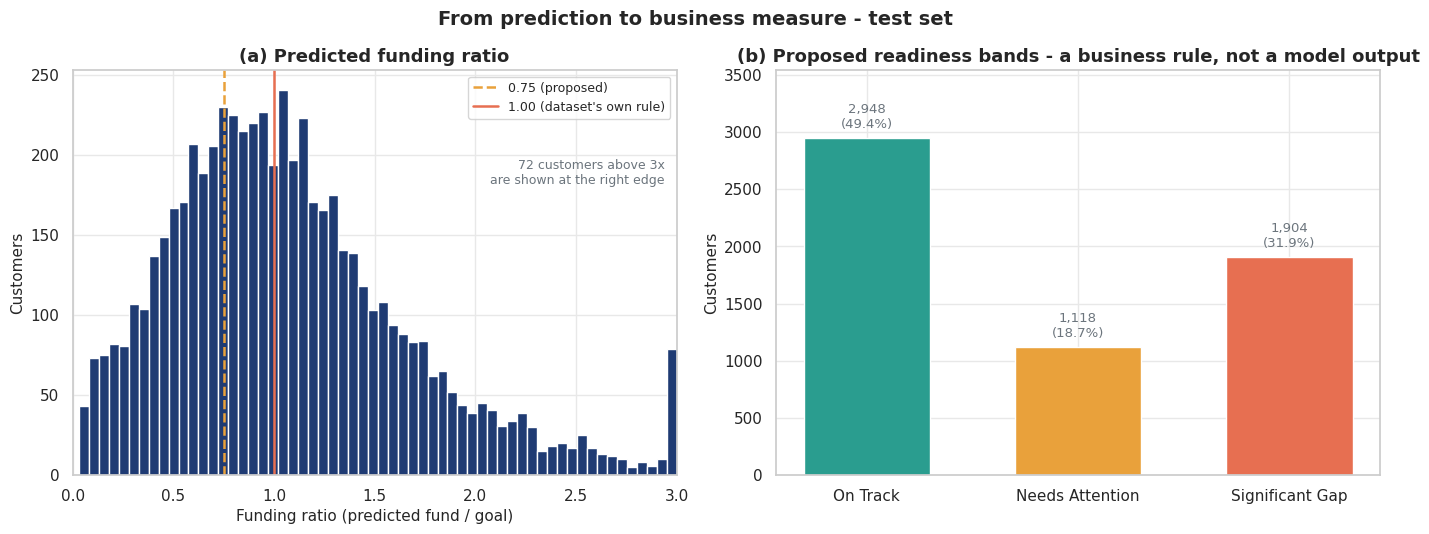

In [10]:
# The goal is a raw customer column, so it comes straight from the test rows.
business_view = pd.DataFrame({
    "Predicted_Retirement_Fund": predicted_dollars,
    "Retirement_Fund_Goal": X_test_raw["Retirement_Fund_Goal"].to_numpy(),
    "Actual_Retirement_Fund": test_actual_dollars,
}, index=X_test_raw.index)

# Shortfall convention: positive means projected to fall short of the goal.
business_view["Funding_Gap"] = (business_view.Retirement_Fund_Goal
                                - business_view.Predicted_Retirement_Fund)
business_view["Funding_Ratio"] = (business_view.Predicted_Retirement_Fund
                                  / business_view.Retirement_Fund_Goal)
READINESS_BINS = [-np.inf, NEEDS_ATTENTION_RATIO, ON_TRACK_RATIO, np.inf]
READINESS_LABELS = ["Significant Gap", "Needs Attention", "On Track"]

business_view["Proposed_Readiness"] = pd.cut(
    business_view.Funding_Ratio, bins=READINESS_BINS, labels=READINESS_LABELS, right=False)

print(f"Retirement goals present for all test customers: "
      f"{int(business_view.Retirement_Fund_Goal.notna().sum()):,} of {len(business_view):,}")
print(f"Goals greater than zero (funding ratio always defined): "
      f"{bool((business_view.Retirement_Fund_Goal > 0).all())}")
print()

readiness_counts = business_view.Proposed_Readiness.value_counts().reindex(
    ["On Track", "Needs Attention", "Significant Gap"])
portfolio_summary = pd.DataFrame([
    ("Customers scored", f"{len(business_view):,}"),
    ("Average predicted retirement fund", f"${business_view.Predicted_Retirement_Fund.mean():,.0f}"),
    ("Average retirement fund goal", f"${business_view.Retirement_Fund_Goal.mean():,.0f}"),
    ("Average funding ratio", f"{business_view.Funding_Ratio.mean():.2f}"),
    ("Median funding ratio", f"{business_view.Funding_Ratio.median():.2f}"),
    ("Customers projected to fall short of goal",
     f"{(business_view.Funding_Gap > 0).mean() * 100:.1f}%"),
    ("Total projected shortfall across those customers",
     f"${business_view.Funding_Gap.clip(lower=0).sum() / 1e9:,.2f}B"),
    ("Proposed band: On Track", f"{readiness_counts['On Track']:,} ({readiness_counts['On Track'] / len(business_view) * 100:.1f}%)"),
    ("Proposed band: Needs Attention", f"{readiness_counts['Needs Attention']:,} ({readiness_counts['Needs Attention'] / len(business_view) * 100:.1f}%)"),
    ("Proposed band: Significant Gap", f"{readiness_counts['Significant Gap']:,} ({readiness_counts['Significant Gap'] / len(business_view) * 100:.1f}%)"),
], columns=["Portfolio measure", "Value"]).set_index("Portfolio measure")

print(portfolio_summary.to_string())

# How the derived measures line up with the KPI columns the dataset already carries.
dataset_kpis = raw_data.loc[X_test_raw.index, KPI_COLUMNS]
gap_is_surplus = np.allclose(
    dataset_kpis.Funding_Gap,
    business_view.Actual_Retirement_Fund - business_view.Retirement_Fund_Goal, atol=1e-6)
model_readiness_flag = (business_view.Funding_Ratio >= ON_TRACK_RATIO).astype(int)
readiness_agreement = (model_readiness_flag.to_numpy()
                       == dataset_kpis.RetirementReady.to_numpy()).mean() * 100

print("\nCross-check against the KPI columns the dataset already contains:")
print(f"   Dataset Funding_Gap equals (Actual - Goal), i.e. a surplus: {gap_is_surplus}")
print(f"   This report's Funding_Gap is the same quantity with the opposite sign, "
      f"calculated from the prediction instead of the actual.")
print(f"   Dataset Readiness_Score equals (Actual / Goal): "
      f"{np.allclose(dataset_kpis.Readiness_Score, business_view.Actual_Retirement_Fund / business_view.Retirement_Fund_Goal, atol=1e-4)}")
print(f"   Customers the dataset flags as RetirementReady: {dataset_kpis.RetirementReady.mean() * 100:.1f}%")
print(f"   Customers the model-based rule flags as On Track: {model_readiness_flag.mean() * 100:.1f}%")
print(f"   The two flags agree for {readiness_agreement:.1f}% of test customers.")
print(f"\n   The {100 - readiness_agreement:.1f}% disagreement is prediction error crossing the")
print("   1.00 boundary. Customers near that line are exactly the ones a business")
print("   process should treat with the least confidence.")

# --- FIGURE 4: funding ratio and the proposed readiness bands ------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5.4))

ratio_limit = 3.0
clipped_ratio = business_view.Funding_Ratio.clip(upper=ratio_limit)
axes[0].hist(clipped_ratio, bins=60, color=NAVY, edgecolor="white")
axes[0].axvline(NEEDS_ATTENTION_RATIO, color=AMBER, lw=1.8, ls="--",
                label=f"{NEEDS_ATTENTION_RATIO:.2f} (proposed)")
axes[0].axvline(ON_TRACK_RATIO, color=CORAL, lw=1.8,
                label=f"{ON_TRACK_RATIO:.2f} (dataset's own rule)")
axes[0].set_xlabel("Funding ratio (predicted fund / goal)")
axes[0].set_ylabel("Customers")
axes[0].set_title("(a) Predicted funding ratio")
axes[0].set_xlim(0, ratio_limit)
axes[0].legend(frameon=True, fontsize=9)
axes[0].text(0.98, 0.72,
             f"{int((business_view.Funding_Ratio > ratio_limit).sum()):,} customers above "
             f"{ratio_limit:.0f}x\nare shown at the right edge",
             transform=axes[0].transAxes, ha="right", fontsize=9, color=SLATE)

band_colours = {"On Track": TEAL, "Needs Attention": AMBER, "Significant Gap": CORAL}
positions = np.arange(len(readiness_counts))
axes[1].bar(positions, readiness_counts.to_numpy(),
            color=[band_colours[name] for name in readiness_counts.index],
            edgecolor="white", width=0.6)
axes[1].set_xticks(positions)
axes[1].set_xticklabels(readiness_counts.index)
axes[1].set_ylabel("Customers")
axes[1].set_title("(b) Proposed readiness bands - a business rule, not a model output")
axes[1].set_ylim(0, readiness_counts.max() * 1.2)
for position, value in zip(positions, readiness_counts):
    axes[1].text(position, value + readiness_counts.max() * 0.03,
                 f"{value:,}\n({value / len(business_view) * 100:.1f}%)",
                 ha="center", fontsize=9.5, color=SLATE)

fig.suptitle("From prediction to business measure - test set",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "06_funding_ratio.png", dpi=300, bbox_inches="tight",
            facecolor="white")
plt.show()

---
## 12. Customer-Level Example

Three real test customers, selected by a fixed rule so the same three appear on every run:
the customers whose predicted fund sits closest to the 10th, 50th and 90th percentile of
all test predictions. Nothing is invented.

The point of the example is to show what a business user would actually see on a screen,
and what they should *not* read into it. The actual fund and the prediction error are shown
alongside, because a readiness band presented without its error margin is misleading.

In [11]:
# Deterministic selection: nearest predicted value to a fixed percentile. np.argmin
# returns the first match, so ties resolve the same way on every run.
EXAMPLE_PERCENTILES = {"Lower (10th pct)": 10, "Typical (50th pct)": 50, "Upper (90th pct)": 90}

example_positions = {
    label: int(np.argmin(np.abs(predicted_dollars - np.percentile(predicted_dollars, percentile))))
    for label, percentile in EXAMPLE_PERCENTILES.items()
}

example_rows = {}
for label, position in example_positions.items():
    transformed = X_test_transformed.iloc[position]
    customer = business_view.iloc[position]
    example_rows[label] = {
        "Age": f"{transformed['Age']:.0f}",
        "Annual salary": f"${transformed['AnnualSalary']:,.0f}",
        "Retirement account balance": f"${transformed['RetirementAccountBalance']:,.0f}",
        "Savings rate": f"{transformed['SavingsRate'] * 100:.1f}%",
        "Employer pension": "Yes" if transformed["EmployerPension_Yes"] == 1 else "No",
        "Years until retirement": f"{transformed['YearsUntilRetirement']:.0f}",
        "Predicted retirement fund": format_money(customer.Predicted_Retirement_Fund),
        "Retirement fund goal": format_money(customer.Retirement_Fund_Goal),
        "Funding gap (goal - predicted)": format_money(customer.Funding_Gap),
        "Funding ratio": f"{customer.Funding_Ratio:.2f}",
        "Proposed readiness band": str(customer.Proposed_Readiness),
        "Actual fund (for reference only)": format_money(customer.Actual_Retirement_Fund),
        "Prediction error": format_signed_money(
            customer.Predicted_Retirement_Fund - customer.Actual_Retirement_Fund),
    }

customer_example = pd.DataFrame(example_rows)
customer_example.index.name = "Customer attribute"

print("Test-set positions selected (deterministic):")
for label, position in example_positions.items():
    print(f"   {label:<20} row {position:>5}   customer index {X_test_raw.index[position]}")
print()
print(customer_example.to_string())

print("\nHow a business user should read the middle column:")
typical = business_view.iloc[example_positions["Typical (50th pct)"]]
print(f"   The model estimates this customer will reach "
      f"${typical.Predicted_Retirement_Fund:,.0f} against a goal of "
      f"${typical.Retirement_Fund_Goal:,.0f}.")
print(f"   That is a funding ratio of {typical.Funding_Ratio:.2f}, which falls in the "
      f"proposed '{typical.Proposed_Readiness}' band.")
print(f"   The band is a flag for review, not a conclusion. For half of test customers this")
print(f"   model is off by more than ${final_scores['MedianAE ($)']:,.0f}, which is "
      f"{final_scores['MedianAE ($)'] / typical.Retirement_Fund_Goal:.0%} of this customer's goal -")
print(f"   large enough to move them across a band boundary on its own.")
# What band would this customer land in if the actual fund were known?
typical_actual_ratio = typical.Actual_Retirement_Fund / typical.Retirement_Fund_Goal
typical_actual_band = pd.cut([typical_actual_ratio], bins=READINESS_BINS,
                             labels=READINESS_LABELS, right=False)[0]
print(f"\n   That is not hypothetical here. Using the actual fund instead of the prediction,")
print(f"   this customer's ratio is {typical_actual_ratio:.2f} and the band would be "
      f"'{typical_actual_band}'.")
print(f"   Across the whole test set the two flags agree {readiness_agreement:.1f}% of the time,")
print("   so a band shown without its error margin overstates what the model knows.")
print("\n   This is a prompt to look closer, not personalised financial advice. Nothing here")
print("   recommends how any customer should save or invest.")

Test-set positions selected (deterministic):
   Lower (10th pct)     row  5790   customer index 12983
   Typical (50th pct)   row   437   customer index 13658
   Upper (90th pct)     row  4820   customer index 8985

                                 Lower (10th pct) Typical (50th pct) Upper (90th pct)
Customer attribute                                                                   
Age                                            51                 42               48
Annual salary                             $44,500           $101,037         $212,707
Retirement account balance               $187,930           $349,719       $1,147,763
Savings rate                                 9.2%               4.8%            11.8%
Employer pension                               No                Yes              Yes
Years until retirement                         17                 25               16
Predicted retirement fund                $996,664         $3,428,612       $7,679,191
Retirement

---
## 13. Business Use Case

If a model like this were fitted on representative real data, it could sit as a
decision-support component inside workflows such as:

- **financial planning platforms** — populating a projected fund alongside a customer's goal;
- **wealth-management teams** — an initial triage view showing which clients appear furthest
  from their goal and warrant a conversation;
- **digital banking experiences** — a retirement projection tile in an app;
- **advisor decision-support** — background context before a review meeting, with the model's
  drivers visible so an advisor can judge whether the estimate looks sensible;
- **customer retirement-readiness dashboards** — portfolio and segment views for a business
  owner.

In every case the model supplies an input to a human process. It does not make the decision,
and no specific organisation is claimed to be deploying it.

---
## 14. What the Model Can and Cannot Tell Us

**The model CAN:**

- estimate an expected retirement fund from the customer features available to it;
- identify patterns in this synthetic dataset and reproduce them consistently;
- support comparison of a predicted fund against a stated retirement goal;
- show where its own prediction error is larger and smaller across segments;
- explain which features it relied on, both overall and for an individual prediction.

**The model CANNOT:**

- prove causality - importance is model reliance, not cause and effect;
- guarantee any customer's retirement outcome;
- replace professional financial advice;
- demonstrate that it works on real customers, because it has only ever seen synthetic data;
- eliminate uncertainty - half of test customers are missed by more than the median absolute
  error reported in Section 6;
- establish that a predicted amount will actually be achieved.

---
## 15. Business Risks and Limitations

Carried forward from Notebooks 1-5 rather than newly asserted here:

| Risk | What it means for the business |
|---|---|
| Synthetic data | Every number in this project describes generated data. Nothing is evidence about real savers. |
| Prediction uncertainty | Errors are material at the individual level and can move a customer across a readiness band on their own. |
| Uneven error across segments | Relative error is largest for lower-income customers and those furthest from retirement; dollar error is largest for the highest-income customers. A single headline accuracy figure hides both. |
| Correlated features | Engineered features overlap with the columns they were built from, so individual importance scores should not be read as separate effects. |
| Data quality | Missing values were imputed with training medians. Real-world data will be messier, and imputation is invisible to the end user. |
| Distribution shift | A real customer population would differ from this generated one, so performance would have to be re-established, not assumed. |
| Explainability limits | SHAP explains this model, not the financial system the data represents, and its contributions are in log space rather than dollars. |
| Privacy | Real deployment would use detailed personal financial data, with the consent, retention and access controls that implies. |
| Financial governance | A projected retirement fund shown to a customer is close to regulated advice. Sign-off, disclosure and record-keeping would be required. |
| Real-world validation | Required before any production use. |
| Model monitoring | Performance, input distributions and segment-level error would need ongoing tracking, not a one-off sign-off. |

---
## 16. Recommended Business Workflow

The path from a customer record to a business action, and the point at which the machine
learning stops and business rules begin.

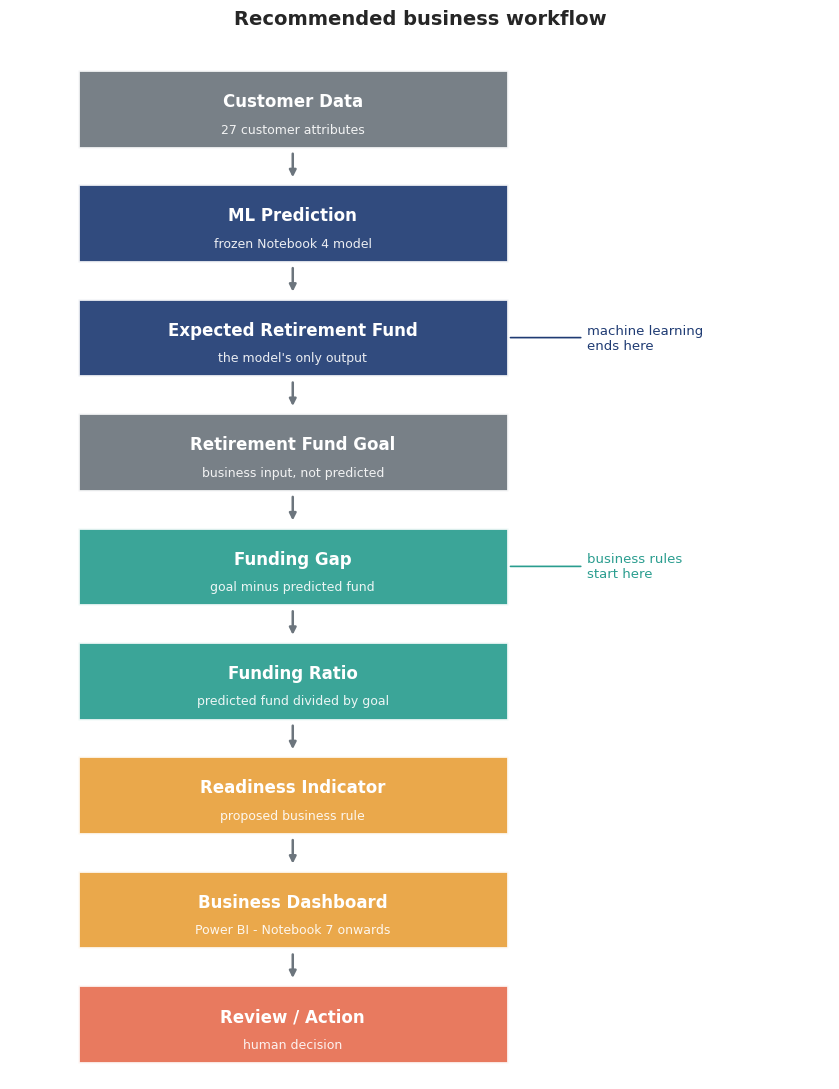

In [12]:
# --- FIGURE 5: the business workflow -------------------------------------
WORKFLOW_STEPS = [
    ("Customer Data", SLATE, "27 customer attributes"),
    ("ML Prediction", NAVY, "frozen Notebook 4 model"),
    ("Expected Retirement Fund", NAVY, "the model's only output"),
    ("Retirement Fund Goal", SLATE, "business input, not predicted"),
    ("Funding Gap", TEAL, "goal minus predicted fund"),
    ("Funding Ratio", TEAL, "predicted fund divided by goal"),
    ("Readiness Indicator", AMBER, "proposed business rule"),
    ("Business Dashboard", AMBER, "Power BI - Notebook 7 onwards"),
    ("Review / Action", CORAL, "human decision"),
]

fig, ax = plt.subplots(figsize=(8.5, 11))
box_height, gap = 0.72, 0.34
top = len(WORKFLOW_STEPS) * (box_height + gap)

for index, (title, colour, note) in enumerate(WORKFLOW_STEPS):
    bottom = top - (index + 1) * (box_height + gap)
    ax.add_patch(plt.Rectangle((0.12, bottom), 0.76, box_height, facecolor=colour,
                               edgecolor="white", lw=2, alpha=0.92))
    ax.text(0.5, bottom + box_height * 0.60, title, ha="center", va="center",
            fontsize=12, fontweight="bold", color="white")
    ax.text(0.5, bottom + box_height * 0.24, note, ha="center", va="center",
            fontsize=9, color="white", alpha=0.9)
    if index < len(WORKFLOW_STEPS) - 1:
        ax.annotate("", xy=(0.5, bottom - gap + 0.04), xytext=(0.5, bottom - 0.03),
                    arrowprops=dict(arrowstyle="-|>", color=SLATE, lw=1.8))

ax.annotate("machine learning\nends here", xy=(0.88, top - 3 * (box_height + gap) + 0.36),
            xytext=(1.02, top - 3 * (box_height + gap) + 0.36), fontsize=9.5,
            color=NAVY, va="center",
            arrowprops=dict(arrowstyle="-", color=NAVY, lw=1.2))
ax.annotate("business rules\nstart here", xy=(0.88, top - 5 * (box_height + gap) + 0.36),
            xytext=(1.02, top - 5 * (box_height + gap) + 0.36), fontsize=9.5,
            color=TEAL, va="center",
            arrowprops=dict(arrowstyle="-", color=TEAL, lw=1.2))

ax.set_xlim(0, 1.45)
ax.set_ylim(-0.15, top - gap + 0.22)
ax.axis("off")
ax.set_title("Recommended business workflow", fontsize=14, fontweight="bold", pad=16)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "06_business_workflow.png", dpi=300, bbox_inches="tight",
            facecolor="white")
plt.show()

---
## 17. Final Recommendations

1. **Use the model as decision support, never as an autonomous decision-maker.** Its output
   is an estimate with a material error margin; a person should own every customer-facing
   action that follows from it.
2. **Validate on representative real-world data before any production use.** Nothing in this
   project establishes that the model works outside its synthetic dataset. Treat the current
   metrics as a demonstration of method, not a performance guarantee.
3. **Set the readiness thresholds deliberately, and own them as a business decision.** The
   bands in Section 11 are illustrative. A business owner, not a modeller, should choose them,
   document the reasoning, and record that they are not a validated financial standard.
4. **Monitor performance by segment, not just in aggregate.** The headline metrics hide the
   fact that relative error is worst for lower-income and long-horizon customers, and dollar
   error is worst for the highest-income customers.
5. **Monitor the input population for drift.** Retrain or recalibrate when the customer mix
   moves away from what the model was fitted on.
6. **Review large prediction errors as a standing process.** A small number of customers
   drive most of the squared error; they deserve inspection rather than silent inclusion.
7. **Keep explanations attached to predictions.** Showing which features drove an estimate
   lets a reviewer judge whether it is sensible, and is close to a practical requirement for
   any customer-facing financial projection.

## 18. Final Project Summary

```text
Problem          Estimate a customer's expected retirement fund
      |
Data             30,000 synthetic customer records, 150 exact duplicates removed
      |
Preprocessing    Leakage-safe pipeline, 40 model features, training-only statistics
      |
Baseline         Gradient Boosting selected from seven candidates
      |
Improvement      Tuning plus a log target with a smearing correction, chosen on CV
      |
Evaluation       Sealed test set, scored once, reproduced independently in Notebook 5
      |
Explainability   Built-in, permutation and SHAP importance agree on the leading features
      |
Business         Funding gap, funding ratio and a proposed readiness band
```

The project demonstrates a complete machine-learning workflow: estimating an expected
retirement fund and translating that estimate into a potential retirement-readiness
decision-support framework.

**Because the dataset is synthetic, this is a demonstration of the methodology and not
evidence about real customer outcomes.** The numbers describe a generated dataset. The
transferable result is the process: leakage control, honest evaluation on a sealed test set,
explainability, and a clear separation between what the model predicts and what the business
decides.

## 19. Next Step - Power BI

The next stage is no longer machine-learning development. The model is frozen and the business
measures are defined. What remains is an interactive, business-facing dashboard. No Power BI
work is done in this notebook; this section records the requirements.

**Portfolio-level views**

- total customers scored
- average predicted retirement fund
- average funding ratio
- count and share of customers with a funding gap
- total projected shortfall
- performance and error by segment

**Customer-level views**

- customer financial profile
- predicted retirement fund
- retirement fund goal
- funding gap and funding ratio
- proposed readiness indicator, shown with its error margin
- the important model drivers for that customer

**Segment-level views**

- income group
- age
- years until retirement
- employer pension
- other business-meaningful segments

The scored customer-level table that feeds the dashboard is a **Notebook 7** deliverable, not
a Notebook 6 one. Notebook 7 covers the deployment and prediction pipeline; this notebook only
documents what the dashboard needs.

---
## 20. Final Verification

In [13]:
# --- Save the Notebook 6 summary tables ----------------------------------
business_summary = pd.DataFrame(
    [{"Section": "Model performance", "Item": METRIC_LABELS[metric],
      "Value": format_metric(metric, final_scores[metric])} for metric in HEADLINE_METRICS]
    + [{"Section": "Business measures", "Item": item, "Value": value}
       for item, value in portfolio_summary.Value.items()]
)

saved_artifacts = {
    "06_business_summary.csv": (business_summary, False),
    "06_segment_summary.csv": (business_segments, False),
    "06_customer_business_example.csv": (customer_example, True),
}
for filename, (table, with_index) in saved_artifacts.items():
    table.to_csv(ARTIFACTS_DIR / filename, index=with_index)

expected_figures = ["06_baseline_vs_final.png", "06_error_by_segment.png",
                    "06_top_model_drivers.png", "06_funding_ratio.png",
                    "06_business_workflow.png"]

print("Artifacts written:")
for filename in saved_artifacts:
    print(f"   {filename:<36} {(ARTIFACTS_DIR / filename).stat().st_size / 1024:>7.1f} KB")
print("Figures written:")
for filename in expected_figures:
    print(f"   {filename:<36} {(FIGURES_DIR / filename).stat().st_size / 1024:>7.1f} KB")

# --- Verification --------------------------------------------------------
protected_hashes_after = hash_files(PROTECTED_FILES)
changed_files = [path for path, digest in PROTECTED_HASHES_BEFORE.items()
                 if protected_hashes_after.get(path) != digest]

business_numbers = np.concatenate([
    business_view.Predicted_Retirement_Fund.to_numpy(),
    business_view.Funding_Gap.to_numpy(),
    business_view.Funding_Ratio.to_numpy(),
    np.array(list(final_scores.values())),
])

checks = [
    ("Every required project file was found",
     all(path.exists() for path in PATHS.values())),
    ("Notebook 4 final configuration was read",
     set(final_config) >= {"candidate", "target_scale", "smearing_factor",
                           "model_params", "n_model_features"}),
    ("Notebook 5 evaluation results were read (baseline and final rows)",
     {BASELINE_NAME, FINAL_NAME} <= set(evaluation_results.index)),
    ("Notebook 5 segment, permutation and SHAP results were read",
     len(segment_errors) > 0 and len(permutation_importance_results) > 0
     and len(shap_importance) > 0),
    ("Test split rebuilt to the Notebook 2 shape",
     len(X_test_raw) == 5970 and len(X_train_raw) == final_config["n_training_rows"]),
    ("Model feature count matches the saved configuration",
     len(model_feature_names) == final_config["n_model_features"]),
    ("Predictions reproduce the Notebook 5 test metrics",
     reproduction_gap <= REPRODUCTION_TOLERANCE),
    ("NO MODEL WAS TRAINED - the notebook only calls predict()",
     gradient_boosting.n_estimators_ == final_config["model_params"]["n_estimators"]),
    ("NO TUNING - hyperparameters equal the saved configuration",
     all(gradient_boosting.get_params()[key] == value
         for key, value in final_config["model_params"].items())),
    ("Reported KPIs come from the reproduced predictions, not typed values",
     all(np.isclose(final_scores[metric], float(nb5_final[metric]))
         for metric in HEADLINE_METRICS)),
    ("All business metrics are finite",
     bool(np.isfinite(business_numbers).all())),
    ("Predicted funds are strictly positive",
     bool((business_view.Predicted_Retirement_Fund > 0).all())),
    ("Retirement goals are present and positive for every test customer",
     bool(business_view.Retirement_Fund_Goal.notna().all()
          and (business_view.Retirement_Fund_Goal > 0).all())),
    ("Funding gap equals goal minus predicted fund",
     bool(np.allclose(business_view.Funding_Gap,
                      business_view.Retirement_Fund_Goal
                      - business_view.Predicted_Retirement_Fund))),
    ("Funding ratio equals predicted fund divided by goal",
     bool(np.allclose(business_view.Funding_Ratio,
                      business_view.Predicted_Retirement_Fund
                      / business_view.Retirement_Fund_Goal))),
    ("Every test customer received a proposed readiness band",
     int(business_view.Proposed_Readiness.isna().sum()) == 0),
    ("Readiness bands sum to the test-set size",
     int(readiness_counts.sum()) == len(business_view)),
    ("Customer example selection is deterministic",
     example_positions == {
         label: int(np.argmin(np.abs(predicted_dollars
                                     - np.percentile(predicted_dollars, percentile))))
         for label, percentile in EXAMPLE_PERCENTILES.items()}),
    ("Notebook 6 artifacts exist",
     all((ARTIFACTS_DIR / filename).exists() for filename in saved_artifacts)),
    ("Notebook 6 figures exist",
     all((FIGURES_DIR / filename).exists() for filename in expected_figures)),
    ("NO EXISTING PROJECT FILE WAS MODIFIED (re-hashed at the end)",
     len(changed_files) == 0),
    ("Notebook 6 wrote only inside its own artifacts/ and figures/ folders",
     all(Path.cwd() in path.parents or Path.cwd() == path.parent
         for path in list(ARTIFACTS_DIR.iterdir()) + list(FIGURES_DIR.iterdir()))),
]

verification = pd.DataFrame(checks, columns=["Check", "Passed"]).set_index("Check")
print()
print(verification.to_string())

if changed_files:
    print("\nFiles that changed unexpectedly:")
    for path in changed_files:
        print(f"   {path}")

assert verification.Passed.all(), "One or more Notebook 6 checks failed."

print(f"\n{'=' * 74}")
print("NOTEBOOK 6 - FINAL BUSINESS REPORT: ALL VERIFICATION CHECKS PASSED")
print(f"{'=' * 74}")
print(f"   Model            {final_config['candidate']} (loaded, not trained)")
print(f"   Test customers   {len(X_test_raw):,}")
print(f"   Dollar RMSE      ${final_scores['RMSE ($)']:,.0f}   "
      f"Median absolute error ${final_scores['MedianAE ($)']:,.0f}")
print(f"   Business measure funding gap and funding ratio derived after prediction")
print(f"   Files protected  {len(PROTECTED_HASHES_BEFORE)} existing project files, "
      f"{len(changed_files)} changed")
print(f"   Next stage       Notebook 7 (deployment pipeline), then the Power BI dashboard")
print("\n   Reminder: the dataset is synthetic. These results demonstrate the method;")
print("   they are not evidence about real customers or real retirement outcomes.")

Artifacts written:
   06_business_summary.csv                  1.0 KB
   06_segment_summary.csv                   1.7 KB
   06_customer_business_example.csv         0.7 KB
Figures written:
   06_baseline_vs_final.png               243.6 KB
   06_error_by_segment.png                376.9 KB
   06_top_model_drivers.png               209.0 KB
   06_funding_ratio.png                   247.7 KB
   06_business_workflow.png               244.1 KB

                                                                      Passed
Check                                                                       
Every required project file was found                                   True
Notebook 4 final configuration was read                                 True
Notebook 5 evaluation results were read (baseline and final rows)       True
Notebook 5 segment, permutation and SHAP results were read              True
Test split rebuilt to the Notebook 2 shape                              True
Model feature co